# 12 - Task 3: features built from raw text, and the baseline re-run

**The premise.** Three rounds have now optimised the *model* while holding the feature
representation fixed, and all three ran out of room: round 3's ensemble gained 0.0017
locally and nothing on Kaggle, round 4's best combiner gained 0.0075 out-of-fold AUC and
0.0017 on Kaggle. The representation is the part nobody has touched.

**Why the supplied features are the wrong basis for this particular test set.** They are
top-5000 TF-IDF over lemmas with stop words removed, which is a pure *content* signal.
The COLING paper shows the test split is drawn from CUDRT, IELTS, NLPeer, PeerSum and
MixSet, none of which appear in training, so the content vocabulary of the test set is
substantially not the vocabulary the features were built on. Function words, punctuation,
orthography and layout do transfer across topics, and the course preprocessing removed
precisely those.

`src/text_features.py` builds nine blocks that put them back. A to G are cheap
per-document statistics; H and I are the two vectorizers.

**Everything is fitted on train only.** Blocks B-G are per-document functions and cannot
leak. Block A uses a pinned stop-word vocabulary and is not fitted at all. Only H and I
are fitted transforms, and section 3 asserts they saw no test text.

**What "did it improve" means here.** The supplied TF-IDF is re-run as a control in
section 5 of *this* notebook, on the same folds, in the same session. Comparing against
the stored `baseline_results.csv` from several weeks ago would confound the feature
change with anything else that has drifted since.

## 0. Setup

In [20]:
# Reload src/ helpers on every cell execution. Round 5 adds src/text.py,
# src/text_features.py and src/clustering.py while these notebooks are open, and a
# plain `import` caches the module in the kernel - so a fixed helper keeps failing
# with the OLD traceback until the kernel is restarted. With this, saving the .py
# is enough.
%load_ext autoreload
%autoreload 2

# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import paths, data, evaluation, tuning, ensemble, text
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

from src import text_features as tf

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load raw text and the locked split

Nothing re-splits. `dev_idx` is the same 16,000 rows every notebook since 01 has used,
so a score here is comparable to every score already recorded.

In [21]:
train_ids, train_texts, y = text.load_train_text()
test_ids, test_texts = text.load_test_text()

dev_idx = np.load(paths.DATA_PROCESSED / "dev_idx.npy")
holdout_idx = np.load(paths.DATA_PROCESSED / "holdout_idx.npy")
cv = evaluation.make_cv()

assert len(dev_idx) == 16000 and len(holdout_idx) == 4000
assert not set(dev_idx) & set(holdout_idx), "dev and holdout overlap"

y_dev = y[dev_idx]
print(f"train {len(train_texts)}, test {len(test_texts)}, dev {len(dev_idx)}")
print(f"dev machine share {y_dev.mean():.4f}")

train 20000, test 6999, dev 16000
dev machine share 0.6252


## 2. Sanity check: do the known signals reproduce?

The feature builder is new code operating on 27,000 documents, and a silent bug in it
would poison every result downstream. These differences were measured independently, by
a much simpler route, before the builder existed.

| statistic | human | machine |
|---|---|---|
| newlines per document | 7.70 | 4.47 |
| `**` occurrences per document | 0.049 | 0.496 |
| uppercase fraction | 0.0254 | 0.0230 |
| punctuation fraction | 0.0307 | 0.0266 |

In [22]:
summary = text.text_summary(train_texts, y)
print(summary.round(4).to_string())

expected = {"newlines_mean": (7.70, 4.47), "bold_mean": (0.049, 0.496),
            "upper_frac": (0.0254, 0.0230), "punct_frac": (0.0307, 0.0266)}
ok = True
for stat, (want0, want1) in expected.items():
    got0, got1 = summary.loc["label=0", stat], summary.loc["label=1", stat]
    close = (abs(got0 - want0) < 0.05 * want0 + 1e-4
             and abs(got1 - want1) < 0.05 * want1 + 1e-4)
    ok &= close
    print(f"  {stat:16s} got ({got0:.4f}, {got1:.4f})  "
          f"want ({want0}, {want1})  {'ok' if close else 'MISMATCH'}")

assert ok, "raw-text statistics do not match what was measured independently"
print("\nSanity check passed - the corpus is what the exploration described.")

             n  char_mean  char_median  word_mean  newlines_mean  bold_mean  upper_frac  punct_frac
group                                                                                              
label=0   7496  1529.4469       1065.0   261.4636         7.7036     0.0491      0.0254      0.0310
label=1  12504  1445.1233       1198.0   237.5543         4.4676     0.4961      0.0230      0.0266
  newlines_mean    got (7.7036, 4.4676)  want (7.7, 4.47)  ok
  bold_mean        got (0.0491, 0.4961)  want (0.049, 0.496)  ok
  upper_frac       got (0.0254, 0.0230)  want (0.0254, 0.023)  ok
  punct_frac       got (0.0310, 0.0266)  want (0.0307, 0.0266)  ok

Sanity check passed - the corpus is what the exploration described.


## 3. Build and cache the nine blocks

Cached to `data/processed/textfeat_<block>.npz`, so this runs once per machine. The
caches are gitignored like every other derived artifact and rebuilding is deterministic.

Blocks H and I are the expensive ones (two TF-IDF fits over 20,000 documents); A to G
are a single pass over each corpus.

In [23]:
REBUILD = False   # set True to force a rebuild after editing src/text_features.py

built = {}
for block in tf.ALL_BLOCKS:
    if not REBUILD and tf.cache_path(block).exists():
        built[block] = tf.load_block(block)
        print(f"{block:20s} cached")
        continue
    print(f"{block:20s} building ...", flush=True)
    one = tf.build_blocks(train_texts, test_texts, blocks=[block])[block]
    tf.save_block(block, one)
    built[block] = one
    print(f"{block:20s} built {one['train'].shape}")

A_function_words     cached
B_punctuation        cached
C_casing             cached
D_structure          cached
E_length             cached
F_diversity          cached
G_readability        cached
H_char_ngrams        cached
I_word_ngrams        cached


In [24]:
# Correctness guards. Each catches a specific failure mode that would otherwise surface
# only as a mediocre score weeks later.
inventory = []
for block, entry in built.items():
    Xtr, Xte = entry["train"], entry["test"]
    assert Xtr.shape[0] == 20000 and Xte.shape[0] == 6999, (block, Xtr.shape, Xte.shape)
    assert Xtr.shape[1] == Xte.shape[1] == len(entry["names"]), block
    assert np.isfinite(Xtr.data).all() and np.isfinite(Xte.data).all(), block
    inventory.append({"block": block, "n_features": Xtr.shape[1],
                      "density": Xtr.nnz / (Xtr.shape[0] * Xtr.shape[1]),
                      "mb": (Xtr.data.nbytes + Xtr.indices.nbytes) / 1e6})

print(pd.DataFrame(inventory).round(4).to_string(index=False))
print("\nEvery block: 20000 train rows, 6999 test rows, names aligned, all finite.")

           block  n_features  density       mb
A_function_words         318   0.1287   9.8241
   B_punctuation          37   0.1892   1.6797
        C_casing           5   0.5874   0.7048
     D_structure          10   0.4957   1.1896
        E_length          10   0.9939   2.3853
     F_diversity           5   0.9948   1.1938
   G_readability           5   0.9972   1.1966
   H_char_ngrams       20000   0.0746 238.6045
   I_word_ngrams       20000   0.0089  28.3895

Every block: 20000 train rows, 6999 test rows, names aligned, all finite.


In [25]:
# Leakage guard. H and I are the only fitted transforms. Refitting block I on the
# training text alone must reproduce the cached matrix exactly; had the cache been built
# on train+test, the vocabulary would differ and this would fail.
probe_tr, probe_te, probe_names = tf.word_ngram_features(train_texts, test_texts)
cached = built["I_word_ngrams"]

same_vocab = probe_names == cached["names"]
same_matrix = bool(abs(probe_tr - cached["train"]).max() < 1e-6) if same_vocab else False
print(f"block I vocabulary identical on refit:   {same_vocab}")
print(f"block I train matrix identical on refit: {same_matrix}")
assert same_vocab and same_matrix, \
    "block I is not reproducible from train alone - it may have been fitted on test"
print("\nNo vectorizer has seen test text.")

block I vocabulary identical on refit:   True
block I train matrix identical on refit: True

No vectorizer has seen test text.


## 4. The representations to compare

| key | contents |
|---|---|
| `tfidf_supplied` | the course's 5,000 lemma features, **the control** |
| `block_<X>` | each new block alone, to see what each is worth |
| `style_all` | blocks A-G, the cheap non-vectorizer features |
| `text_all` | blocks A-I, everything built from raw text |
| `supplied_plus_style` | the course features plus A-G |
| `supplied_plus_all` | the course features plus everything |

The single-block rows are what make section 5 diagnostic rather than a horse race. If
`block_H` alone is close to `text_all`, the gain is one block and the other eight are
decoration, which is a cheaper and more honest thing to report.

In [26]:
from scipy import sparse as sp

X_supplied, _, _ = data.load_train_features(sparse=True)

STYLE = ["A_function_words", "B_punctuation", "C_casing", "D_structure",
         "E_length", "F_diversity", "G_readability"]


def rep(name, rows=None):
    '''Build one named representation, restricted to `rows` (default: dev).'''
    rows = dev_idx if rows is None else rows
    if name == "tfidf_supplied":
        return X_supplied[rows]
    if name.startswith("block_"):
        block = [b for b in tf.ALL_BLOCKS if b.startswith(name[6:] + "_")][0]
        return built[block]["train"][rows]
    if name == "style_all":
        return tf.stack(built, STYLE)[0][rows]
    if name == "text_all":
        return tf.stack(built, tf.ALL_BLOCKS)[0][rows]
    if name == "supplied_plus_style":
        return sp.hstack([X_supplied[rows], tf.stack(built, STYLE)[0][rows]],
                         format="csr")
    if name == "supplied_plus_all":
        return sp.hstack([X_supplied[rows], tf.stack(built, tf.ALL_BLOCKS)[0][rows]],
                         format="csr")
    raise KeyError(name)


REPRESENTATIONS = (["tfidf_supplied"]
                   + [f"block_{b[0]}" for b in tf.ALL_BLOCKS]
                   + ["style_all", "text_all", "supplied_plus_style",
                      "supplied_plus_all"])
for name in REPRESENTATIONS:
    print(f"{name:22s} {rep(name).shape}")

tfidf_supplied         (16000, 5000)
block_A                (16000, 318)
block_B                (16000, 37)
block_C                (16000, 5)
block_D                (16000, 10)
block_E                (16000, 10)
block_F                (16000, 5)
block_G                (16000, 5)
block_H                (16000, 20000)
block_I                (16000, 20000)
style_all              (16000, 390)
text_all               (16000, 40390)
supplied_plus_style    (16000, 5390)
supplied_plus_all      (16000, 45390)


## 5. The baseline suite

Five to six models spanning the families in `baseline_results.csv`, under the locked
5-fold stratified CV on Macro F1. **Default hyperparameters throughout**: this measures
the representation, and tuning each model per representation would confound the two and
cost days.

`tuning.run_trial` caches every result by a hash of its configuration, so this is
resumable and merges across teammates through `data/processed/tuning_trials/` exactly as
the round-4 searches did. No new ledger.

**Change `ME` and nothing else.** Split by cost: blocks A-G are small and fast, H and I
are 20,000-column sparse matrices and much slower.

In [27]:
ASSIGNMENTS = {
    "cliffton": ["tfidf_supplied", "block_A"],
    "brian":    [f"block_{b[0]}" for b in tf.DENSE_BLOCKS],
    "jovyan":   ["block_H", "block_I", "text_all"],
    "koko":     ["style_all", "supplied_plus_style", "supplied_plus_all"],
}

ME = "koko"   # <-- THE ONLY LINE TO CHANGE

n_pos, n_neg = int((y_dev == 1).sum()), int((y_dev == 0).sum())

MODELS = {
    "lightgbm":     lambda: LGBMClassifier(class_weight="balanced", verbose=-1,
                                           n_jobs=-1, random_state=42),
    "xgboost":      lambda: XGBClassifier(tree_method="hist", eval_metric="logloss",
                                          scale_pos_weight=n_neg / n_pos, n_jobs=-1,
                                          random_state=42),
    "logreg":       lambda: LogisticRegression(max_iter=2000, class_weight="balanced",
                                               random_state=42),
    "linearsvc":    lambda: LinearSVC(class_weight="balanced", max_iter=5000,
                                      dual="auto", random_state=42),
    "complementnb": lambda: ComplementNB(),
}

# HistGB needs dense input, so it only runs where densifying is affordable. Skipping it
# elsewhere is printed rather than silent.
DENSE_ONLY = {"histgb": lambda: HistGradientBoostingClassifier(random_state=42)}
DENSE_LIMIT = 400

print(f"{ME} runs: {ASSIGNMENTS[ME]}")

koko runs: ['style_all', 'supplied_plus_style', 'supplied_plus_all']


In [28]:
for rep_name in ASSIGNMENTS[ME]:
    X = rep(rep_name)
    print(f"\n=== {rep_name}  {X.shape}", flush=True)

    todo = dict(MODELS)
    if X.shape[1] <= DENSE_LIMIT:
        todo.update(DENSE_ONLY)
    else:
        print(f"  (histgb skipped: {X.shape[1]} columns is too many to densify)")

    for clf_name, make in todo.items():
        Xf = X.toarray() if clf_name == "histgb" else X
        # ComplementNB requires non-negative input. Block E carries log counts and
        # block G carries Flesch scores, both of which go negative.
        if clf_name == "complementnb" and Xf.min() < 0:
            print(f"  {clf_name:14s} skipped (representation has negative values)")
            continue
        params = {"clf": clf_name, "representation": rep_name}
        record = tuning.run_trial(f"repr_{rep_name}", ME, make(), params, Xf, y_dev, cv)
        print(f"  {clf_name:14s} {record['mean']:.4f} +/- {record['std']:.4f}")


=== style_all  (16000, 390)
  lightgbm       0.8452 +/- 0.0056
  xgboost        0.8458 +/- 0.0080
  logreg         0.6903 +/- 0.0034
  linearsvc      0.7369 +/- 0.0069
  complementnb   skipped (representation has negative values)
  histgb         0.8435 +/- 0.0034

=== supplied_plus_style  (16000, 5390)
  (histgb skipped: 5390 columns is too many to densify)
  lightgbm       0.8584 +/- 0.0051
  xgboost        0.8570 +/- 0.0060
  logreg         0.6944 +/- 0.0038
  linearsvc      0.7939 +/- 0.0058
  complementnb   skipped (representation has negative values)

=== supplied_plus_all  (16000, 45390)
  (histgb skipped: 45390 columns is too many to densify)
  lightgbm       0.8795 +/- 0.0053
  xgboost        0.8747 +/- 0.0051
  logreg         0.7030 +/- 0.0069
  linearsvc      0.5332 +/- 0.1408
  complementnb   skipped (representation has negative values)


### Commit your trials

```bash
git add data/processed/tuning_trials/
git commit -m "feat: representation baselines for <your representations>"
git push
```

Section 6 needs everyone's, so `git pull` first.

## 6. The merged comparison

The control matters more than the winner. `tfidf_supplied` re-run here must land close to
`baseline_results.csv` (LightGBM 0.73914, LinearSVC 0.72278, ComplementNB 0.65798). If it
lands far *above* those, something leaked and no other row can be trusted.

In [29]:
frames = []
for rep_name in REPRESENTATIONS:
    trials = tuning.load_trials(f"repr_{rep_name}")
    for _, row in trials.iterrows():
        frames.append({"representation": rep_name, "clf": row["params"]["clf"],
                       "owner": row["owner"], "mean": row["mean"], "std": row["std"]})

results = pd.DataFrame(frames)
assert len(results), "no representation trials on disk - has anyone run section 5?"

missing = [r for r in REPRESENTATIONS if r not in set(results["representation"])]
if missing:
    print(f"still waiting on: {missing}\n")

table = (results.pivot_table(index="representation", columns="clf", values="mean")
         .reindex([r for r in REPRESENTATIONS
                   if r in set(results["representation"])]))
table["best"] = table.max(axis=1)
print(table.round(4).to_string())

STORED = {"lightgbm": 0.73914, "linearsvc": 0.72278, "complementnb": 0.65798}
if "tfidf_supplied" in table.index:
    print("\nControl check against baseline_results.csv:")
    for clf, stored in STORED.items():
        if clf in table.columns and pd.notna(table.loc["tfidf_supplied", clf]):
            got = float(table.loc["tfidf_supplied", clf])
            flag = "LEAK?" if got > stored + 0.02 else "ok"
            print(f"  {clf:14s} now {got:.4f}  stored {stored:.4f}  "
                  f"delta {got - stored:+.4f}  {flag}")

clf                  complementnb  histgb  lightgbm  linearsvc  logreg  xgboost    best
representation                                                                         
tfidf_supplied             0.6580     NaN    0.7303     0.7228  0.7246   0.7190  0.7303
block_A                    0.5852  0.7067    0.7273     0.6163  0.5865   0.7206  0.7273
block_B                    0.5758  0.6847    0.7012     0.6319  0.6338   0.6987  0.7012
block_C                    0.5213  0.5544    0.5874     0.5520  0.5432   0.5871  0.5874
block_D                    0.5167  0.6384    0.6588     0.6318  0.6318   0.6587  0.6588
block_E                    0.5091  0.7007    0.7092     0.6246  0.6240   0.7029  0.7092
block_F                    0.5585  0.6785    0.6821     0.5296  0.5386   0.6805  0.6821
block_G                       NaN  0.4749    0.5660     0.5621  0.5627   0.5612  0.5660
block_H                    0.6494     NaN    0.8188     0.7872  0.7835   0.8058  0.8188
block_I                    0.669

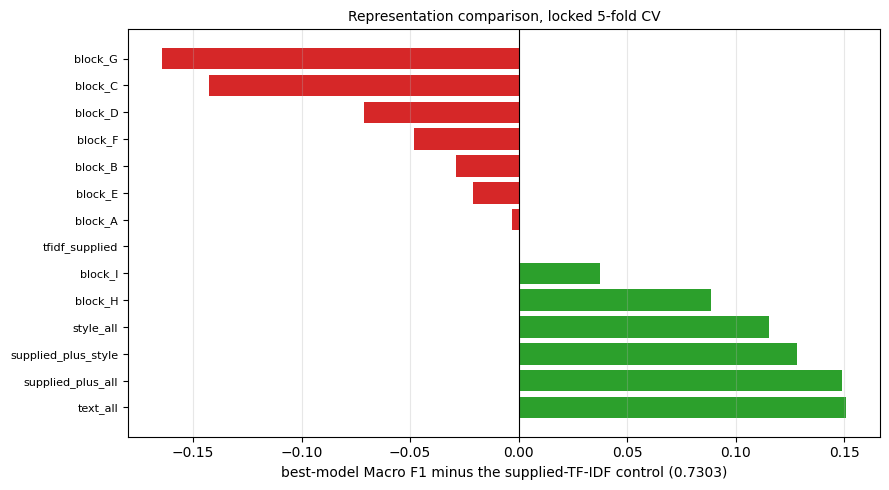

control (supplied TF-IDF, best model): 0.7303

representation
text_all               0.1508
supplied_plus_all      0.1492
supplied_plus_style    0.1281
style_all              0.1155
block_H                0.0885
block_I                0.0373
tfidf_supplied         0.0000
block_A               -0.0030
block_E               -0.0211
block_B               -0.0291
block_F               -0.0482
block_D               -0.0715
block_C               -0.1429
block_G               -0.1643

CV std is roughly 0.004, so treat anything under about 0.008 as a tie.


In [30]:
control = float(table.loc["tfidf_supplied", "best"])
gains = (table["best"] - control).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["tab:gray" if i == "tfidf_supplied"
          else ("tab:green" if v > 0 else "tab:red") for i, v in gains.items()]
ax.barh(range(len(gains)), gains.to_numpy(), color=colors)
ax.set_yticks(range(len(gains)), gains.index, fontsize=8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"best-model Macro F1 minus the supplied-TF-IDF control ({control:.4f})")
ax.set_title("Representation comparison, locked 5-fold CV", fontsize=10)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(FIGURES / "representation_comparison.png", dpi=120)
plt.show()

results.to_csv(paths.DATA_PROCESSED / "representation_results.csv", index=False)
print(f"control (supplied TF-IDF, best model): {control:.4f}\n")
print(gains.round(4).to_string())
print("\nCV std is roughly 0.004, so treat anything under about 0.008 as a tie.")

## 7. Holdout check on the two candidate feature sets

Two feature sets go forward from the section 6 table:

| set | blocks | why |
|---|---|---|
| `text_all` | A to I | the top of the table at 0.8811 |
| `robust_AH` | A + H | function words and character n-grams only, dropping every block that encodes formatting, casing, layout, length, diversity or readability |

`robust_AH` is a new combination and has no row in section 6, so it is scored here under
the same locked CV before anything else is read.

**Why not `style_all` or `supplied_plus_all`.** `supplied_plus_all` ties `text_all`
(0.8795 against 0.8811, inside the 0.008 band) with 5,000 more columns, so it is the same
result for more work. `style_all` looks steadier across models, but the instability
elsewhere is entirely LinearSVC (0.5569 on `text_all`, 0.5332 +/- 0.1408 on
`supplied_plus_all`), and that is a feature-scaling failure rather than a property of the
representation: block E carries log counts and block G carries Flesch scores in the tens,
which swamp TF-IDF columns in a hinge loss. Across the three tree models `text_all` spans
0.0104 and `style_all` 0.0023, both tight, and `text_all` sits 0.035 higher. A tree model
is what ships, so the linear columns should not decide the pick.

**What the holdout can and cannot do.** These 4,000 rows have not been touched since the
split was locked, so this is a genuine check that the section 5 comparison did not overfit
the folds. But holdout is carved from train, is 100% UUID-format, and shares every domain
with dev. **It cannot say anything about transfer.** Landing near the CV number means the
search was honest and nothing more, so do not read a good holdout score as a prediction of
the leaderboard.

In [32]:
FEATURE_SETS = {
    # The top of the section 6 table. supplied_plus_all ties it (0.8795 against 0.8811,
    # inside the 0.008 band) using 5000 more columns, so the supplied features add
    # nothing once raw text is present.
    "text_all":  list(tf.ALL_BLOCKS),
    # Function words plus character n-grams. Drops every block encoding formatting,
    # casing, layout, length, diversity or readability, and drops the content-heavy
    # word n-grams. What is left is the classic domain-invariant stylometry pair.
    "robust_AH": ["A_function_words", "H_char_ngrams"],
}

y_hold = y[holdout_idx]
hold_share = float(y_hold.mean())

hold_rows = []
for set_name, blocks in FEATURE_SETS.items():
    Xall, _, _ = tf.stack(built, blocks)

    # robust_AH is a new combination and has no row in the section 6 table, so score it
    # under the same locked CV. text_all is read from the table rather than recomputed.
    if set_name in table.index:
        cv_mean = float(table.loc[set_name, "lightgbm"])
    else:
        rec = tuning.run_trial(f"repr_{set_name}", ME, MODELS["lightgbm"](),
                               {"clf": "lightgbm", "representation": set_name},
                               Xall[dev_idx], y_dev, cv)
        cv_mean = rec["mean"]

    clf = MODELS["lightgbm"]()
    clf.fit(Xall[dev_idx], y_dev)
    s = ensemble.member_score(clf, Xall[holdout_idx])

    hold_rows.append({
        "features": set_name,
        "n_features": Xall.shape[1],
        "cv_mean": round(cv_mean, 4),
        "holdout_default": round(
            evaluation.macro_f1(y_hold, (s >= 0.5).astype(int)), 4),
        # Share-matched at the holdout's OWN true share, so this reflects ranking
        # quality rather than calibration.
        "holdout_at_true_share": round(
            ensemble.macro_f1_at_share(s, y_hold, hold_share), 4),
    })
    print(f"{set_name:12s} scored", flush=True)

hold_table = pd.DataFrame(hold_rows)
hold_table["cv_minus_holdout"] = (hold_table["cv_mean"]
                                  - hold_table["holdout_at_true_share"]).round(4)
print()
print(hold_table.to_string(index=False))
print(f"\nholdout true machine share {hold_share:.4f}")
print("Reference: supplied-feature LightGBM holdout Macro F1 0.7437 "
      "(data/processed/holdout_metrics.csv).")
print("A small cv_minus_holdout means the section 5 comparison did not overfit the "
      "folds. It says nothing about the test set, which is a different domain.")

text_all     scored


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

robust_AH    scored

 features  n_features  cv_mean  holdout_default  holdout_at_true_share  cv_minus_holdout
 text_all       40390   0.8811           0.8775                 0.8778            0.0033
robust_AH       20318   0.8148           0.8171                 0.8165           -0.0017

holdout true machine share 0.6252
Reference: supplied-feature LightGBM holdout Macro F1 0.7437 (data/processed/holdout_metrics.csv).
A small cv_minus_holdout means the section 5 comparison did not overfit the folds. It says nothing about the test set, which is a different domain.


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 8. Two diagnostics that can speak to transfer without spending a Kaggle slot

Neither needs notebook 13's clusters, and both describe the models section 9 actually
ships, not a proxy.

**8a. Predicted share by test id group.** Notebook 11 measured the round-4 blend on the
supplied features: a single global cut at 0.4996 lands at **0.3782** on the UUID rows and
**0.5482** on the numeric rows. The paper puts the true shares at roughly 0.625 for the
train-like population and 0.531 for the test split. If a raw-text model pushes the numeric
group well above 0.55, it is calling peer reviews machine, which is exactly what keying on
layout and markdown would look like from the outside.

**8b. Where the model's gain actually comes from.** Summing LightGBM's gain importance by
block prefix says in one table whether the model leans on function words and character
n-grams or on formatting counts. Blocks B, C, D and E are the artifact-prone ones. Block B
contains `B_bold_md`, and machine text in train carries `**` at 0.496 occurrences per
document against human 0.049, while the test numeric rows sit at 2.52. **In train that
separates the classes; in test it separates the domains.** The same feature is a strong
class signal in one corpus and a strong domain signal in the other, which is the concrete
mechanism by which a +0.15 CV gain can transfer as nothing.

This section also produces named features, which is a thing the supplied anonymised TF-IDF
columns could never support and which the Task 4 report needs.

In [33]:
masks = text.group_masks(test_ids)
BENCH_SHARE = 0.4996          # the share every current submission uses

# Refit on all 20,000 rows, exactly as a submission would, and score the test set once.
# Reused by 8a, 8b and section 9 so the diagnostics describe the shipped models.
full = {}
for set_name, blocks in FEATURE_SETS.items():
    Xall, Xte, names = tf.stack(built, blocks)
    clf = MODELS["lightgbm"]()
    clf.fit(Xall, y)
    full[set_name] = {"clf": clf, "names": names,
                      "test_scores": ensemble.member_score(clf, Xte)}
    print(f"{set_name:12s} refitted on {Xall.shape[0]} rows, "
          f"scored {Xte.shape[0]} test rows", flush=True)

# 8a. Where a fixed global cut lands within each test id group.
rows = [{"model": "round-4 blend, supplied features",   # 11_group_share section 6
         "uuid_share": 0.3782, "numeric_share": 0.5482}]
for set_name, d in full.items():
    lab = ensemble.threshold_at_share(d["test_scores"], BENCH_SHARE)
    rows.append({"model": f"lightgbm, {set_name}",
                 "uuid_share": round(float(lab[masks["uuid"]].mean()), 4),
                 "numeric_share": round(float(lab[masks["numeric"]].mean()), 4)})

group_table = pd.DataFrame(rows)
group_table["gap"] = (group_table["numeric_share"] - group_table["uuid_share"]).round(4)
print()
print(group_table.to_string(index=False))
print("\nEvery row is at the same global share 0.4996, so only the split differs.")
print("The paper's true shares: about 0.625 train-like, about 0.531 for the test split.")
print("A numeric share well above 0.55 means the model is calling peer reviews machine.")

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


text_all     refitted on 20000 rows, scored 6999 test rows


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


robust_AH    refitted on 20000 rows, scored 6999 test rows

                           model  uuid_share  numeric_share    gap
round-4 blend, supplied features      0.3782         0.5482 0.1700
              lightgbm, text_all      0.4667         0.5128 0.0461
             lightgbm, robust_AH      0.3727         0.5504 0.1777

Every row is at the same global share 0.4996, so only the split differs.
The paper's true shares: about 0.625 train-like, about 0.531 for the test split.
A numeric share well above 0.55 means the model is calling peer reviews machine.


In [34]:
# 8b. Where the gain comes from, aggregated by block. Every feature name starts with
# its block letter (A_fw_, B_bold_md, H_char_, ...), so the first character is the key.
imp_rows = []
for set_name, d in full.items():
    gain = d["clf"].booster_.feature_importance(importance_type="gain")
    letters = np.array([n[0] for n in d["names"]])
    total = gain.sum()
    imp_rows.append({"features": set_name,
                     **{L: round(float(gain[letters == L].sum() / total), 4)
                        for L in sorted(set(letters))}})

imp = pd.DataFrame(imp_rows).set_index("features").fillna(0.0)
print("share of total LightGBM gain, by block")
print(imp.to_string())
# atol is loose because the shares are rounded to 4 dp before summing; nine of them
# can drift further than np.allclose's default tolerance without anything being wrong.
assert np.allclose(imp.sum(axis=1), 1.0, atol=1e-3), "block gains do not sum to 1"

# B, C, D and E are the formatting, casing, layout and length blocks - the ones whose
# train signal is most likely a dataset artifact rather than a property of the writing.
artifact = [c for c in imp.columns if c in set("BCDE")]
if artifact:
    print("\nformatting and length blocks (B, C, D, E) as a share of gain:")
    for name, v in imp[artifact].sum(axis=1).items():
        print(f"  {name:12s} {v:.3f}")

# Named features, which is something the supplied anonymised TF-IDF could never give.
top = full["text_all"]
gain = top["clf"].booster_.feature_importance(importance_type="gain")
print("\ntext_all, top 15 features by gain:")
for i in np.argsort(-gain)[:15]:
    print(f"  {top['names'][i]:30s} {gain[i] / gain.sum():.4f}")

share of total LightGBM gain, by block
                A       B       C       D       E       F       G       H       I
features                                                                         
text_all   0.0173  0.0386  0.0132  0.1091  0.0949  0.1789  0.0051  0.4319  0.1109
robust_AH  0.0905  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.9095  0.0000

formatting and length blocks (B, C, D, E) as a share of gain:
  text_all     0.256
  robust_AH    0.000

text_all, top 15 features by gain:
  H_char_ ,                      0.0853
  F_mattr_100                    0.0796
  D_line_len_max                 0.0603
  F_yules_k                      0.0476
  E_burstiness                   0.0321
  F_ttr                          0.0287
  H_char_ .                      0.0256
  D_hardwrap                     0.0217
  F_hapax_frac                   0.0205
  H_char_ .                      0.0173
  E_log_word                     0.0154
  E_sent_len_std                 0.0144
  B_punct_41

## 9. Write the two submissions

Both files use the section 5 LightGBM config, the models refitted in section 8 on all
20,000 rows, and **the same predicted share 0.4996 as the 0.73754 benchmark**. No blend,
no per-group thresholding, no tuning. The only variable against the benchmark is the
representation, which is the entire point of the comparison.

| file | features | what its score answers |
|---|---|---|
| `text_all_lgbm_share50.csv` | A to I | does the raw-text representation transfer at all? |
| `robust_AH_lgbm_share50.csv` | A + H | is the formatting signal the reason it does or does not? |

Holding the share fixed matters more than it looks. Notebook 09 measured share moving the
leaderboard by ~0.08 across its range against ~0.019 for model choice, so a submission
that changed both would be unreadable.

In [35]:
sample = pd.read_csv(paths.DATA_RAW / "sample_submission.csv", dtype={"id": str})
assert list(test_ids) == list(sample["id"]), "test ids do not match sample_submission"

bench_path = paths.SUBMISSIONS / "ensemble_weights_hill_climb_share50.csv"
bench = (pd.read_csv(bench_path, dtype={"id": str})["label"].to_numpy()
         if bench_path.exists() else None)

batch = {f"{set_name}_lgbm_share50.csv":
         ensemble.threshold_at_share(d["test_scores"], BENCH_SHARE)
         for set_name, d in full.items()}

rows = []
for fname, preds in batch.items():
    data.write_submission(test_ids, preds, fname)

    # Same guards notebook 11 uses. A submission that silently drifts in id order
    # scores like noise and looks like a modelling failure.
    sub = pd.read_csv(paths.SUBMISSIONS / fname, dtype={"id": str})
    assert list(sub.columns) == ["id", "label"], sub.columns
    assert list(sub["id"]) == list(sample["id"]), f"{fname}: id order drifted"
    assert set(sub["label"].unique()) <= {0, 1}, f"{fname}: labels outside 0/1"
    lab = sub["label"].to_numpy()
    assert abs(lab.mean() - BENCH_SHARE) < 1 / len(lab), \
        f"{fname}: share {lab.mean():.4f} != {BENCH_SHARE}"

    rows.append({"file": fname, "share": round(float(lab.mean()), 4),
                 "uuid_share": round(float(lab[masks["uuid"]].mean()), 4),
                 "numeric_share": round(float(lab[masks["numeric"]].mean()), 4),
                 "rows_vs_best": int((lab != bench).sum()) if bench is not None else -1})
    print(f"{fname:30s} OK")

batch_table = pd.DataFrame(rows)
print()
print(batch_table.to_string(index=False))

# Append to the round-5 ledger without clobbering any score already recorded.
ledger = paths.DATA_PROCESSED / "round5_results.csv"
out = batch_table.copy()
out["kaggle_f1"] = np.nan
if ledger.exists():
    prev = pd.read_csv(ledger)
    scored = prev[["file", "kaggle_f1"]].dropna()
    if len(scored):
        out = out.drop(columns="kaggle_f1").merge(scored, on="file", how="left")
    out = pd.concat([prev[~prev["file"].isin(out["file"])], out], ignore_index=True)
out.to_csv(ledger, index=False)

print(f"\nledger: {ledger}")
print("Benchmark ensemble_weights_hill_climb_share50.csv = 0.73754, noise floor 0.0084.")
print("Upload both, then write the scores into the kaggle_f1 column.")

text_all_lgbm_share50.csv      OK
robust_AH_lgbm_share50.csv     OK

                      file  share  uuid_share  numeric_share  rows_vs_best
 text_all_lgbm_share50.csv 0.4996      0.4667         0.5128          1388
robust_AH_lgbm_share50.csv 0.4996      0.3727         0.5504          1222

ledger: C:\Users\Cliffton\Documents\GitHub\2026-50.007-Machine-Learning-GenAI-Content-Detection\data\processed\round5_results.csv
Benchmark ensemble_weights_hill_climb_share50.csv = 0.73754, noise floor 0.0084.
Upload both, then write the scores into the kaggle_f1 column.


## 10. Share sweep on `text_all`

`text_all_lgbm_share50.csv` scored **0.77349**, +0.03595 over the old benchmark and 4.3x
the noise floor. That file inherited its predicted share, 0.4996, from notebook 09, where
it was fitted to a **different model's** score distribution.

**So the "share tuning is closed" verdict from notebook 09 section 9 does not carry over.**
It closed the question for the supplied-feature LightGBM, not for this one. Two facts say
it is worth reopening:

- Share moves the leaderboard by roughly 0.08 across its range against roughly 0.019 for
  model choice (notebook 09), so it is still the largest single lever available.
- Section 8a shows `text_all` distributes its positives very differently from the old
  model: uuid 0.4667 / numeric 0.5128 against the old 0.3782 / 0.5482. A different score
  distribution has no reason to peak at the same cut.

There is also a theoretical reason to expect the peak to have **moved up**. For a perfect
ranker the Macro-F1 optimum sits at the true share; weaker rankers do better by
under-predicting the majority class. The test set's true share is about 0.531, the old
model peaked at 0.4996, and this model ranks better, so the new peak should sit somewhere
between the two rather than below 0.4996. That is a prediction, not a result, and the
sweep is deliberately symmetric so it can be wrong.

| file | share |
|---|---|
| `text_all_lgbm_share44.csv` | 0.44 |
| `text_all_lgbm_share47.csv` | 0.47 |
| `text_all_lgbm_share50.csv` | 0.4996, **already scored 0.77349** |
| `text_all_lgbm_share53.csv` | 0.53 |
| `text_all_lgbm_share56.csv` | 0.56 |

Five points at roughly 0.03 spacing across 0.44 to 0.56. Same model, same features, same
everything else, so the curve isolates the share.

**Submit 0.53 first.** It is the direction the argument above predicts, so it is the single
most informative slot. If it gains, follow with 0.56; if it loses, follow with 0.47 and
treat the upward prediction as falsified.

In [ ]:
SHARES = [0.44, 0.47, 0.53, 0.56]

scores = full["text_all"]["test_scores"]

# The 0.4996 point is already on the leaderboard at 0.77349. The sweep is only a curve if
# every point comes from the same model, so check the refit reproduces the shipped file
# rather than assuming it does.
shipped = pd.read_csv(paths.SUBMISSIONS / "text_all_lgbm_share50.csv",
                      dtype={"id": str})["label"].to_numpy()
n_diff = int((ensemble.threshold_at_share(scores, BENCH_SHARE) != shipped).sum())
print(f"refit vs shipped text_all_lgbm_share50.csv: {n_diff} of {len(shipped)} rows differ")
print("0 means all five points sit on one curve.\n")

rows = []
for share in SHARES:
    fname = f"text_all_lgbm_share{int(round(share * 100)):02d}.csv"
    preds = ensemble.threshold_at_share(scores, share)
    data.write_submission(test_ids, preds, fname)

    sub = pd.read_csv(paths.SUBMISSIONS / fname, dtype={"id": str})
    assert list(sub.columns) == ["id", "label"], sub.columns
    assert list(sub["id"]) == list(sample["id"]), f"{fname}: id order drifted"
    assert set(sub["label"].unique()) <= {0, 1}, f"{fname}: labels outside 0/1"
    lab = sub["label"].to_numpy()
    assert abs(lab.mean() - share) < 1 / len(lab), \
        f"{fname}: share {lab.mean():.4f} != {share}"

    rows.append({"file": fname, "share": round(float(lab.mean()), 4),
                 "uuid_share": round(float(lab[masks["uuid"]].mean()), 4),
                 "numeric_share": round(float(lab[masks["numeric"]].mean()), 4),
                 "rows_vs_best": int((lab != shipped).sum())})
    print(f"  {fname:32s} OK")

sweep_table = pd.DataFrame(rows)
print()
print(sweep_table.to_string(index=False))

out = sweep_table.copy()
out["kaggle_f1"] = np.nan
prev = pd.read_csv(ledger)
already = prev[["file", "kaggle_f1"]].dropna()
if len(already):
    out = out.drop(columns="kaggle_f1").merge(already, on="file", how="left")
out = pd.concat([prev[~prev["file"].isin(out["file"])], out], ignore_index=True)
out.to_csv(ledger, index=False)

print(f"\nledger: {ledger}")
print("Submit share53 first. Benchmark is now text_all_lgbm_share50 at 0.77349, "
      "noise floor 0.0084.")

### Result: the share curve is flat here too, so the sweep stops

| share | Kaggle | vs best |
|---|---|---|
| 0.4996 | **0.77349** | - |
| 0.5299 | 0.77231 | -0.00118 |

**-0.00118 on 212 changed rows is a tie**, seven times inside the 0.0084 noise floor. By
the rule written above before the score came back, a result inside the floor means stop,
and that is what happens: `share44`, `share47` and `share56` stay built but unsubmitted.

**Why not spend one more slot on 0.47 anyway.** Moving share by 0.03 moved the score by
0.0012. Any point inside 0.44 to 0.56 should therefore land within about 0.005 of the
best, which is entirely inside the noise floor. A `share47` submission would return
another tie and answer nothing; the sweep has already established the shape.

**The prediction that the peak moved up is not supported.** It is not falsified either,
because a tie cannot falsify anything, but 0.4996 remains the best measured point and
nothing here argues for moving off it. Recorded as unconfirmed rather than quietly
dropped.

**What the tie does establish, and it is worth a line in the report.** The flat top is a
property of the **task**, not of a particular model. Notebook 09 found 0.45 to 0.55
spanned 0.0047 for the supplied-feature ElasticNet; the same region spans about 0.001 for
a raw-text LightGBM that scores 0.036 higher. Two very different score distributions, same
flatness. Macro F1 on this test set is simply insensitive to predicted share across a wide
band, which retires share as a lever for the rest of the project rather than reopening it
per model.

**Share stays fixed at 0.4996 from here.** Every later comparison holds it there so the
representation or model is the only thing moving.

## Discussion / carry-forward -> `13_clustering.ipynb`

**Both files are scored, and this is the first real gain the project has made.**

| file | local CV | Kaggle | vs benchmark 0.73754 |
|---|---|---|---|
| `text_all_lgbm_share50.csv` | 0.8811 | **0.77349** | **+0.03595** |
| `robust_AH_lgbm_share50.csv` | (section 7) | 0.72405 | -0.01349 |

+0.03595 is **4.3x the 0.0084 noise floor**. Rounds 3 and 4 both landed inside it; this
does not. Changing the representation was the right call and the score says so.

### 1. The artifact hypothesis was wrong

Section 4 of this discussion previously predicted that the formatting blocks were dataset
fingerprints that would not transfer, and that `robust_AH` might therefore beat `text_all`
despite scoring lower locally. **It did not. Stripping blocks B to G and I cost 0.04944 on
the test set**, which is six times the noise floor in the opposite direction from the
prediction.

The reasoning was not unreasonable, it was just wrong: `**` really does occur at 0.496 per
document in train machine text against 0.049 human, and the test numeric rows really do
sit at 2.52. But an elevated base rate in a domain does not stop a feature from carrying
class signal *within* that domain, and evidently it still does. This is exactly what the
paired submission was designed to find out, and it found it out.

### 2. Standard CV ranked these two correctly, which round 5 did not expect

The premise of this round was that standard 5-fold CV is the wrong selection criterion
because it trains and tests on the same domains. On this comparison it was the right one:
`text_all` beat `robust_AH` locally and beat it on Kaggle, in the same order.

The refinement that survives is about **level, not rank**. `text_all` went 0.8811 local to
0.77349 Kaggle, a transfer gap of **0.108**. So CV remains wildly optimistic as an
estimate of test performance and must never be quoted as one, but it was not misleading as
a *ranking* between these two feature sets. That distinction is the honest version and it
should go in the report as a correction to this round's own premise.

### 3. Section 8a turned out to be a working transfer diagnostic

The prediction was that a model keyed on peer-review formatting would push the numeric
group's predicted share well above 0.55. What actually happened is more useful:

| model | uuid share | numeric share | group gap | Kaggle |
|---|---|---|---|---|
| `text_all` | 0.4667 | 0.5128 | **0.0461** | **0.77349** |
| round-4 blend, supplied features | 0.3782 | 0.5482 | 0.1700 | 0.73754 |
| `robust_AH` | 0.3727 | 0.5504 | 0.1777 | 0.72405 |

All three are at the same global share 0.4996, so only the split differs. **The gap is
monotone with the Kaggle score across all three points**, and the direction makes sense: a
model that generalises across the two populations should treat them more evenly than one
keyed on whatever distinguishes them. `robust_AH` is nearly indistinguishable from the
round-4 blend on this measure and scored nearly the same.

Three points is not a law, and it should be treated as a hypothesis rather than a rule.
But it is a **local, free, per-submission** predictor of transfer, which is more than this
project has ever had, and the next few submissions will either confirm or kill it cheaply.

### 4. What this comparison cannot decompose

`robust_AH` dropped blocks B, C, D, E, F, G **and** I together, so the 0.04944 is a joint
figure. Block I alone scored 0.7676 locally, well above every dense block, so it may carry
most of that gap on its own with the formatting blocks contributing little. **Do not
conclude "formatting features are worth 0.049 on the test set" from this.** Notebook 14's
leave-one-family-out grid is what separates them, and it now has a concrete reason to run.

### 5. What still stands from the original reading

- **The control reproduced.** LinearSVC 0.7228 and ComplementNB 0.6580 match
  `baseline_results.csv` exactly; LightGBM came in 0.0088 low because this notebook pins
  `class_weight="balanced"`. A leak inflates a control, never deflates one.
- **Block H carries most of the gain.** Char n-grams alone are +0.0885, 59% of `text_all`'s
  local gain. The mundane one-line summary of round 5 is that character n-grams beat lemma
  TF-IDF on this corpus, and the Kaggle result is consistent with that.
- **Block I beats the supplied features but not cleanly**, since it has 20,000 features
  against 5,000 and the capacity confound is not removed.
- **`supplied_plus_all` ties `text_all`** (0.8795 against 0.8811), so the supplied features
  add nothing once raw text is present.

### Carry forward

**The new benchmark is `text_all_lgbm_share50.csv` at 0.77349.** Everything downstream is
measured against that, not against 0.73754.

1. **Re-tune the predicted share first.** This is the highest-value next step and it is
   cheap. The share 0.4996 was fitted to the *old* model's score distribution in notebook
   09, and share moves the leaderboard by ~0.08 across its range against ~0.019 for model
   choice. A materially better ranker very likely peaks somewhere else, and section 8a
   shows `text_all` distributes its positives quite differently. Two submissions bracketing
   0.4996, for example 0.53 and 0.47, would locate it.
2. **Nothing has been tuned on this representation.** Every hyperparameter in the repo was
   searched against the supplied 5,000 features. LightGBM on 40,390 raw-text columns is
   running on defaults.
3. **Notebook 14 has a sharper question now**: not "which families are artifacts" but
   "how much of the 0.049 is block I and how much is B to G".
4. **Notebook 13's clustering is less load-bearing than planned.** Its purpose was to
   supply a selection criterion to replace standard CV, and section 2 above shows standard
   CV ranked correctly here. Run it for the error analysis and the report, but do not block
   submissions on it.
5. **Still unfinished:** block I at `max_features=5000` to remove the capacity confound.

The methodological write-up for Task 4 now has a genuine arc: a falsifiable prediction was
made in advance, a paired submission was designed to test it, and it came back against the
prediction. That is worth more in the report than a result that merely confirmed what was
expected.